In [8]:
!jupyter nbconvert --to html Thembela .ipynb


[NbConvertApp] WARNING | pattern 'Thembela' matched no files
[NbConvertApp] WARNING | pattern '.ipynb' matched no files
This application is used to convert notebook files (*.ipynb)
        to various other formats.


Options
The options below are convenience aliases to configurable class-options,
as listed in the "Equivalent to" description-line of the aliases.
To see all configurable class-options for some <cmd>, use:
    <cmd> --help-all

--debug
    set log level to logging.DEBUG (maximize logging output)
    Equivalent to: [--Application.log_level=10]
--show-config
    Show the application's configuration (human-readable format)
    Equivalent to: [--Application.show_config=True]
--show-config-json
    Show the application's configuration (json format)
    Equivalent to: [--Application.show_config_json=True]
--generate-config
    generate default config file
    Equivalent to: [--JupyterApp.generate_config=True]
-y
    Answer yes to any questions instead of prompting.
    Equivalen

#### 6. Create a choropleth map showing the unemployment rate within a selected country.

In [105]:
import pandas as pd
import matplotlib.pyplot as plt
import plotly.express as  px
import geopandas as gpd
import json

In [195]:
# Load directly from the URL
sa_provinces = gpd.read_file("https://gist.githubusercontent.com/MeganBeckett/9101ba77bd0af06fd003ea5c99d051ab/raw/eca3b12ed76be816c4dce2c0954752b63bd3f804/sa-provinces.json")

print(sa_provinces.head())
print(sa_provinces.columns)
print(sa_provinces["id"].unique())  # List of provinces included


              id           name  \
0  Northern Cape  Northern Cape   
1  KwaZulu-Natal  KwaZulu-Natal   
2     Free State     Free State   
3   Eastern Cape   Eastern Cape   
4        Limpopo        Limpopo   

                                            geometry  
0  MULTIPOLYGON (((16.487 -28.573, 16.505 -28.565...  
1  MULTIPOLYGON (((28.981 -28.909, 28.926 -28.86,...  
2  MULTIPOLYGON (((28.859 -28.773, 28.859 -28.773...  
3  MULTIPOLYGON (((28.64 -30.131, 28.73 -30.102, ...  
4  MULTIPOLYGON (((26.965 -23.747, 26.962 -23.737...  
Index(['id', 'name', 'geometry'], dtype='object')
['Northern Cape' 'KwaZulu-Natal' 'Free State' 'Eastern Cape' 'Limpopo'
 'North West' 'Mpumalanga' 'Western Cape' 'Gauteng']


In [90]:
df = pd.read_excel("unemployment_rate.xlsx")

In [131]:
df1 = df.drop(index=0)
df1.head()

,"Unemployment rate by province and metro, 15 - 64 years",Jan-Mar 2023,Apr-Jun 2023,Jul-Sep 2023,Oct-Dec 2023
1,Western Cape,21.6,20.9,20.2,20.3
2,Western Cape - Non metro,17.9,17.9,14.5,14.9
3,Western Cape - City of cape Town,17.9,17.9,14.5,14.9
4,Eastern Cape,40.0,39.7,38.8,41.9
5,Eastern Cape - Non Metro,45.6,44.7,43.0,47.1


In [133]:
provinces = df1[~df1["Unemployment rate by province and metro, 15 - 64 years"].str.contains(" - ")]
print(provinces)

   Unemployment rate by province and metro, 15 - 64 years  Jan-Mar 2023  \
1                                        Western Cape              21.6   
4                                        Eastern Cape              40.0   
8                                       Northern Cape              26.6   
9                                          Free State              34.4   
12                                      KwaZulu Natal              30.9   
15                                         North West              38.0   
16                                            Gauteng              34.3   
21                                         Mpumalanga              38.5   
22                                            Limpopo              33.6   

    Apr-Jun 2023  Jul-Sep 2023  Oct-Dec 2023  
1           20.9          20.2          20.3  
4           39.7          38.8          41.9  
8           26.9          26.3          26.9  
9           36.7          38.5          37.0  
12          31

In [143]:
provinces = provinces.rename(columns={"Unemployment rate by province and metro, 15 - 64 years": "Provinces"})
provinces.head(10)

,province,Jan-Mar 2023,Apr-Jun 2023,Jul-Sep 2023,Oct-Dec 2023
1,Western Cape,21.6,20.9,20.2,20.3
4,Eastern Cape,40.0,39.7,38.8,41.9
8,Northern Cape,26.6,26.9,26.3,26.9
9,Free State,34.4,36.7,38.5,37.0
12,KwaZulu Natal,30.9,31.0,29.4,29.5
15,North West,38.0,36.8,38.6,39.0
16,Gauteng,34.3,34.4,33.7,33.8
21,Mpumalanga,38.5,38.4,35.5,34.9
22,Limpopo,33.6,31.6,30.8,30.3


In [151]:
# Calculate row mean across all quarters
provinces["South Afican unemployment rate 2023"] = provinces.loc[:, "Jan-Mar 2023":"Oct-Dec 2023"].mean(axis=1)
print(provinces[["province", "South Afican unemployment rate 2023"]])


         province  South Afican unemployment rate 2023
1    Western Cape                               20.750
4    Eastern Cape                               40.100
8   Northern Cape                               26.675
9      Free State                               36.650
12  KwaZulu Natal                               30.200
15     North West                               38.100
16        Gauteng                               34.050
21     Mpumalanga                               36.825
22        Limpopo                               31.575


In [205]:
provinces1 = provinces.drop(columns=["Oct-Dec 2023","Jan-Mar 2023","Apr-Jun 2023","Jul-Sep 2023","mean_2023"])
provinces1.head()

,province,South Afican unemployment rate 2023
1,Western Cape,20.750
4,Eastern Cape,40.100
8,Northern Cape,26.675
9,Free State,36.650
12,KwaZulu Natal,30.200


In [207]:
provinces1["province"] = provinces1["province"].replace({
    "KwaZulu Natal": "KwaZulu-Natal"
})
provinces1.head()


,province,South Afican unemployment rate 2023
1,Western Cape,20.750
4,Eastern Cape,40.100
8,Northern Cape,26.675
9,Free State,36.650
12,KwaZulu-Natal,30.200


In [305]:
merged = sa_provinces.merge(provinces1, left_on="name", right_on="province")


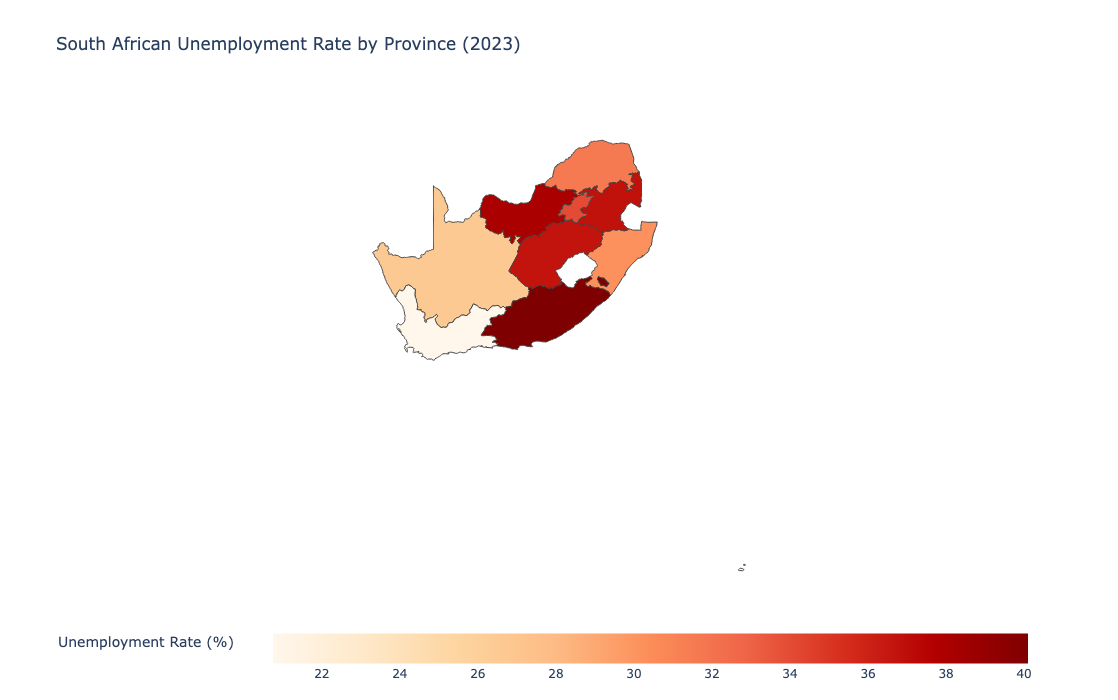

In [364]:
fig = px.choropleth(
    merged,
    geojson=merged,
    featureidkey="properties.id",
    locations="province",
    color="South Afican unemployment rate 2023",  # Use the column name with unemployment means
    color_continuous_scale="OrRd",
    title="South African Unemployment Rate by Province (2023)"
)

  # Adjust map size
fig.update_layout(
    width=1000,
    height=700,
    coloraxis_colorbar=dict(
        title="Unemployment Rate (%)",
        orientation="h",     # horizontal colorbar
        yanchor="bottom",    # position it below the map
        y=-0.15,
        xanchor="center",
        x=0.5
    )
)

# Zoom to the provinces
fig.update_geos(fitbounds="locations", visible=False)

fig.show()


#### 7. Create a proportional symbol map and a graduated symbol map for the same dataset and discuss the differences between the maps. Design an appropriate legend for both maps.

In [281]:
merged["centroid"] = merged.geometry.centroid
merged_points = merged.set_geometry("centroid")


/var/folders/bw/zk_mjw4j7wj3_t08__wfjnl00000gn/T/ipykernel_8428/1218728771.py:1: UserWarning:

Geometry is in a geographic CRS. Results from 'centroid' are likely incorrect. Use 'GeoSeries.to_crs()' to re-project geometries to a projected CRS before this operation.




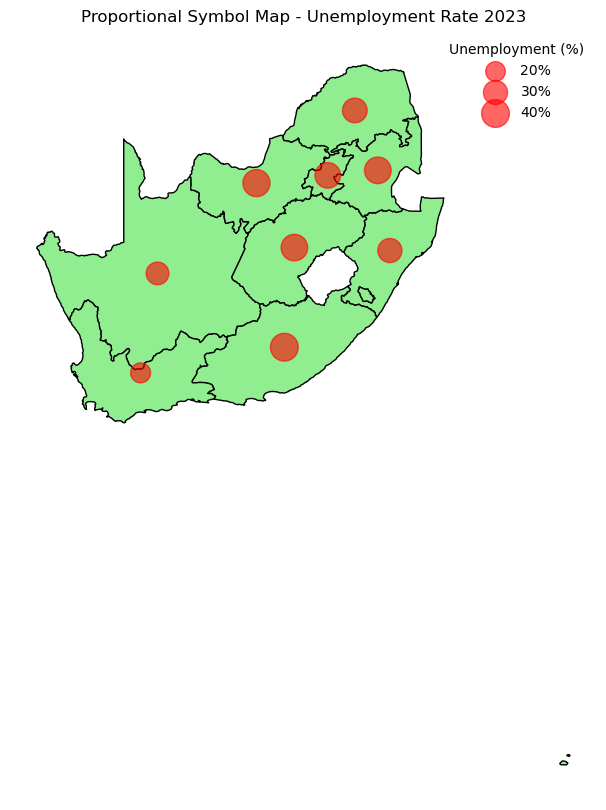

In [287]:
fig, ax = plt.subplots(1, 1, figsize=(10, 10))
# Plot province polygons
merged.plot(ax=ax, color="lightgreen", edgecolor="black")

# Plot proportional symbols
merged_points.plot(
    ax=ax,
    markersize=merged_points["South Afican unemployment rate 2023"] * 10,
    color="red",
    alpha=0.6
)

ax.set_title("Proportional Symbol Map - Unemployment Rate 2023")
ax.axis("off")

# Legend example: manually add 3 circles for reference
for size, label in zip([20, 30, 40], ["20%", "30%", "40%"]):
    ax.scatter([], [], s=size*10, c="red", alpha=0.6, label=label)
ax.legend(scatterpoints=1, frameon=False, title="Unemployment (%)")
plt.show()


#### 8. Sketch a legend for each of the following thematic map types: choropleth, proportional symbol, graduated symbol, isoline, dot density, dasymetric, and flow.

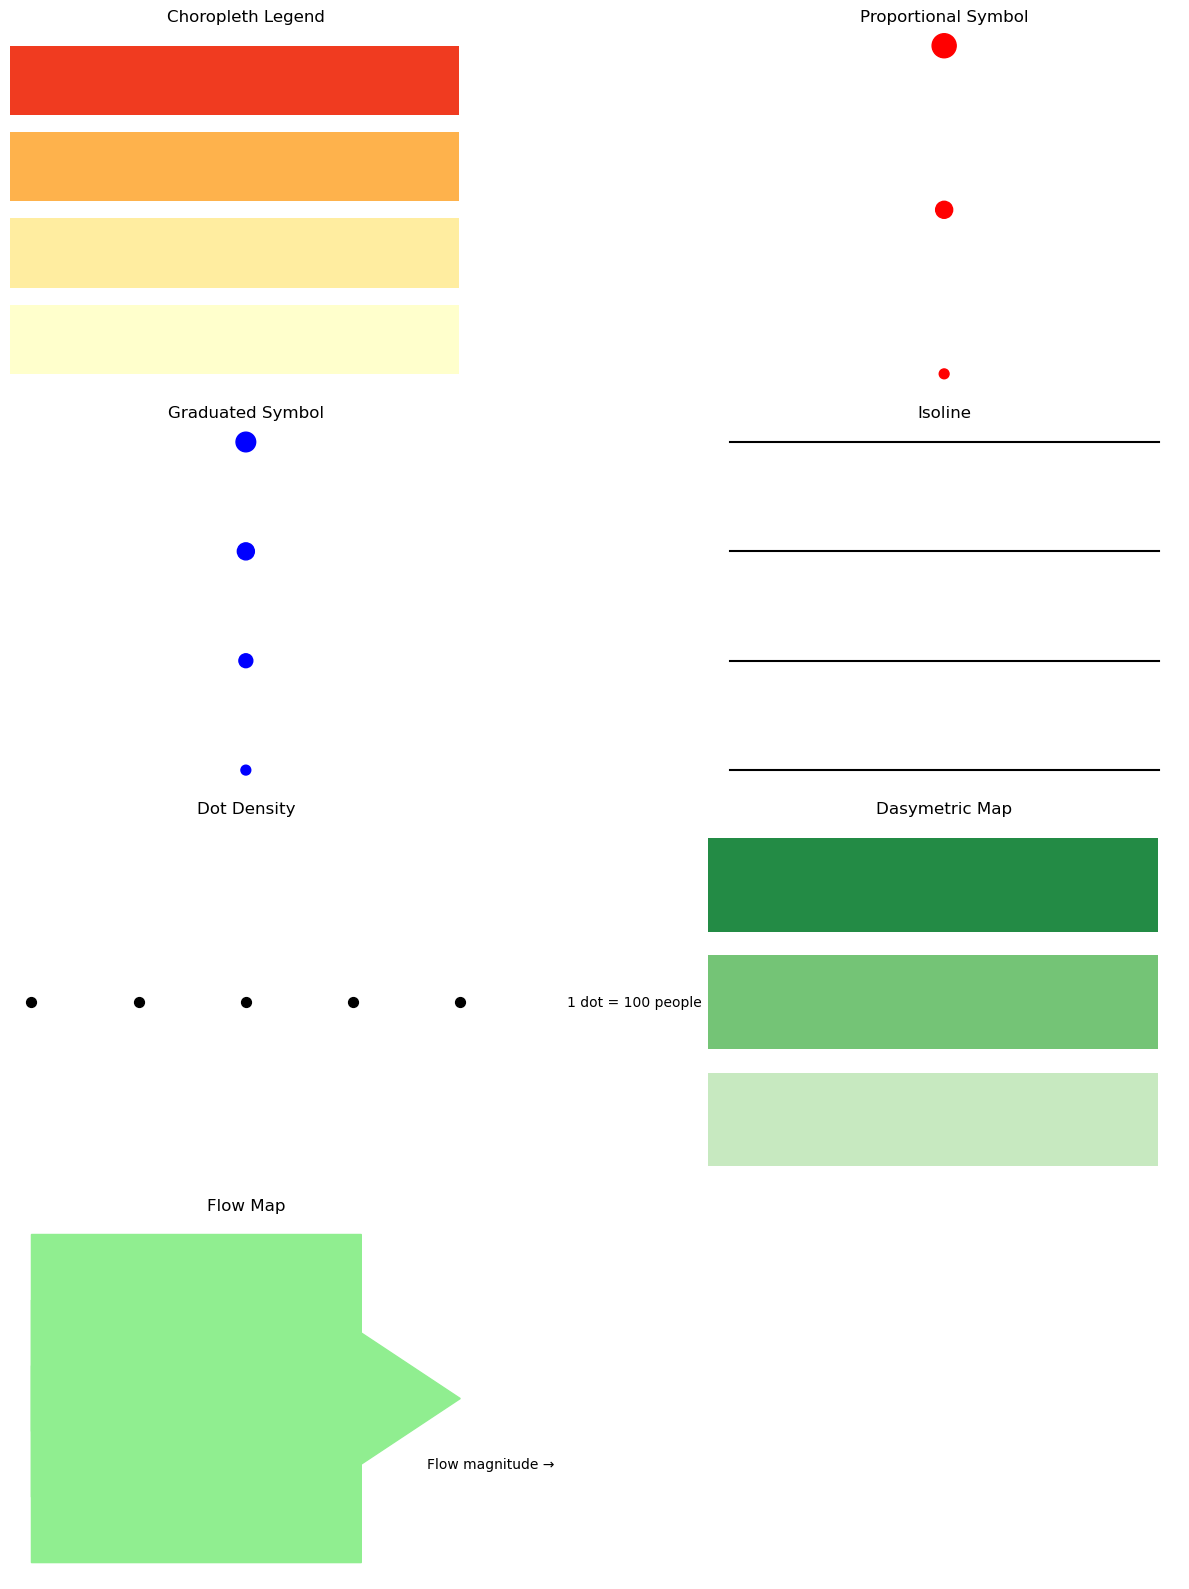

In [299]:
import matplotlib.pyplot as plt
from matplotlib.lines import Line2D
from matplotlib.patches import Circle, Patch, FancyArrow

fig, axes = plt.subplots(4, 2, figsize=(12, 16))
axes = axes.flatten()

# 1️⃣ Choropleth
axes[0].barh([0,1,2,3], [1,1,1,1], color=['#ffffcc','#ffeda0','#feb24c','#f03b20'])
axes[0].set_yticks([0,1,2,3])
axes[0].set_yticklabels(['0-10','10-20','20-30','30-40'])
axes[0].set_title('Choropleth Legend')
axes[0].axis('off')

# 2️⃣ Proportional Symbol
axes[1].scatter([0]*3, [0,1,2], s=[50,150,300], color='red')
axes[1].set_yticks([0,1,2])
axes[1].set_yticklabels(['1000','5000','10000'])
axes[1].set_title('Proportional Symbol')
axes[1].axis('off')

# 3️⃣ Graduated Symbol
axes[2].scatter([0]*4, [0,1,2,3], s=[50,100,150,200], color='blue')
axes[2].set_yticks([0,1,2,3])
axes[2].set_yticklabels(['0-20%','21-30%','31-40%','41-50%'])
axes[2].set_title('Graduated Symbol')
axes[2].axis('off')

# 4️⃣ Isoline
for y in [0,1,2,3]:
    axes[3].plot([0,1], [y,y], color='black')
axes[3].set_yticks([0,1,2,3])
axes[3].set_yticklabels(['0','100','200','300'])
axes[3].set_title('Isoline')
axes[3].axis('off')

# 5️⃣ Dot Density
axes[4].scatter([0.1,0.2,0.3,0.4,0.5], [0]*5, s=50, color='black')
axes[4].text(0.6, 0, '1 dot = 100 people', va='center')
axes[4].set_title('Dot Density')
axes[4].axis('off')

# 6️⃣ Dasymetric
axes[5].barh([0,1,2], [1,1,1], color=['#c7e9c0','#74c476','#238b45'])
axes[5].set_yticks([0,1,2])
axes[5].set_yticklabels(['Low','Medium','High'])
axes[5].set_title('Dasymetric Map')
axes[5].axis('off')

# 7️⃣ Flow
for x, width in zip([0.1,0.3,0.5], [1,3,5]):
    axes[6].arrow(0,0,x,0, width=0.05*width, head_width=0.1, color='lightgreen')
axes[6].text(0.6, -0.05, 'Flow magnitude →', va='center')
axes[6].set_title('Flow Map')
axes[6].axis('off')

# Remove empty subplot
axes[7].axis('off')

plt.tight_layout()
plt.show()


<div style="font-family: 'Times New Roman'; font-size: 12pt; line-height: 2;">
References 
</div>

<div style="font-family: 'Times New Roman'; font-size: 12pt; line-height: 2;">

MacEachren, A.M., 1995. How Maps Work: Representation, Visualization, and Design. New York: Guilford Press.

Slocum, T.A., McMaster, R.B., Kessler, F.C. and Howard, H.H., 2009. Thematic Cartography and Geovisualization (3rd ed.). Upper Saddle River, NJ: Pearson/Prentice Hall.

Tobler, W.R., 1979. Smooth pycnophylactic interpolation for geographical regions. Journal of the American Statistical Association, 74(367), pp. 519–530.
</div>